In [1]:
import numpy
import matplotlib.pyplot as plt
import torch
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from scipy.stats import wasserstein_distance_nd

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
#CHANGES

class VarAutoencoder_128(nn.Module):

    def __init__(self, latentDims, loadPretrained, conditionedOn):
        super().__init__()
        self.conditionedOn = conditionedOn
        self.latentDims = latentDims
        self.conditionDims = self.getConditionDims()
        self.encoder = nn.Sequential(
            nn.Linear(3+self.conditionDims, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 40),
            nn.ReLU(),
            nn.Linear(40, 20),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDims+self.conditionDims, 20),
            nn.ReLU(),
            nn.Linear(20, 40),
            nn.ReLU(),
            nn.Linear(40, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
        self.linear1 = nn.Linear(20, self.latentDims)
        self.linear2 = nn.Linear(20, self.latentDims)
        self.G = torch.distributions.Normal(0, 1)
        self.losses = []
        
        if loadPretrained==None:
            print('Untrained model initialized. CondtionedVars: ', conditionedOn)
        else:
            print('Loading pretrained model: ' + loadPretrained)
            self.load_state_dict(torch.load(loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape)

    def sample(self, label, num_samples=1):
        
        mean = 0
        std = 1

        if label.dim()==1:
            label = label.unsqueeze(0)
        samples = torch.normal(mean, std, (num_samples,self.latentDims))
        z_cond = torch.cat((samples, label), dim=1)
        return self.decoder(z_cond)

    def forward(self, x, y, returnLatent=False):
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        if returnLatent==True:
            return output, mu, logvar, z
        return output, mu, logvar

    def getConditionDims(self):    
        if self.conditionedOn=="piri":
            return 6
        elif self.conditionedOn=="piririm":
            return 9
        elif self.conditionedOn=="piripim":
            return 9
        elif self.conditionedOn=="piririmpim":
            return 12

In [4]:
# Defining loss functions 

loss_1 = nn.MSELoss()
def loss_2(mu, logvar):
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu ** 2 - torch.exp(logvar), dim = 1), dim = 0).sum()

In [5]:
def modelTraining(data_loader, epochs, beta1, beta2, test_data_loader):
    
    return_reconstructions = False
    losses = []
    r_norms = None
    r_new = None
    for epoch in range(epochs):
        VAE.train()
        r_epoch = None
                
        # At the start of epoch, evaluate validation error.
        val_loss = 0
        for (image_t, label_t) in test_data_loader:
            reconstruction_t, mu_t, logvar_t = VAE(image_t, label_t)
            val_loss += loss_1(reconstruction_t, image_t).item() # MSE loss only on validation set
        
        for (image, label) in data_loader:
                
            # Feed through the network
            reconstruction, mu, logvar = VAE(image, label)
            # Calculate loss function
            l1 = loss_1(reconstruction, image)
            l2 = loss_2(mu, logvar)
            loss = beta1*l1 + beta2*l2
            losses.append([loss.item(), beta1*l1.item(), beta2*l2.item(), val_loss])
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            if return_reconstructions and epoch==epochs-1:
                with torch.no_grad():
                    if r_epoch is None:
                        r_epoch = reconstruction
                    else:
                        r_epoch = torch.cat( (r_epoch, reconstruction), dim=0)
                        
        print(f'E{epoch+1}:',round(losses[-1][0]*1000,4), round(losses[-1][1]*1000,4), round(losses[-1][2]*1000,4), round(losses[-1][3]*1000,4))

    return r_epoch, losses

In [6]:
# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/bistable/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 20
train_split = 0.8

# Sample simulation files randomly
fnums = numpy.random.choice(2500, n_datasets)
print(fnums)
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)

# Dataset - training data
#dataset.shape

[1224  200 1045  701 1707 1137  835  936   88 1871  328   31   47  568
  182 1616  504  656 1865  383]


In [28]:
# CHANGES
# Select conditioned variables: piri - [r_n, v_n], piririm - [v_n, r_n, r_n-1], 
#$piripim - [v_n, r_n, v_n-1], piririmpim - [v_n, r_n, r_n-1, v_n-1]
conditionedOn = 'piririm'

# Reforming data for input ; datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim total

# Number of datasets for training
n_datasets = dataset.shape[0]

# Extracting desired vectors from dataset

r_aux = dataset[:, :, -3:] # r_n
r_nxt = torch.roll(r_aux, -1, 1) # r_n+1
r_prev = torch.roll(r_aux, 1, 1) # r_n-1
v = dataset[:, :, 4:7] # v_n
v_prev = torch.roll(v, 1, 1) # v_n-1


# Cut out first & last datapoint for consistency
r_aux = r_aux[:, 1:-1].flatten(end_dim=1)
r_nxt = r_nxt[:, 1:-1].flatten(end_dim=1)
r_prev = r_prev[:, 1:-1].flatten(end_dim=1)
v = v[:, 1:-1].flatten(end_dim=1)
v_prev = v_prev[:, 1:-1].flatten(end_dim=1)


if conditionedOn == 'piri':
    conditionalVars = torch.cat((r_aux, v), dim = 1) # r_n + v_n
elif conditionedOn == 'piririm':
    conditionalVars = torch.cat((v, r_aux, r_prev), dim = 1) # v_n + r_n + r_n-1
elif conditionedOn == 'piripim':
    conditionalVars = torch.cat((v, r_aux, v_prev), dim = 1)
elif conditionedOn == 'piririmpim':
    conditionalVars = torch.cat((v, r_aux, r_prev, v_prev), dim = 1)
else:
    print('Invalid model type')



# Split data: first 20% test, remaining 80% test.
split_ind = int(0.2*len(r_aux))

# Rebuild data for model Input: R_n+1 (3), condition: r_n, velocity_n (6)
test_data = torch.utils.data.TensorDataset(r_nxt[:split_ind], conditionalVars[:split_ind])
data = torch.utils.data.TensorDataset(r_nxt[split_ind:], conditionalVars[split_ind:])

r_aux.shape, r_nxt.shape, v.shape, conditionalVars.shape, len(test_data), len(data), conditionalVars[:2] #, r_aux[:3], r_nxt[:3], v[:3], r_v[:3]

(torch.Size([199960, 3]),
 torch.Size([199960, 3]),
 torch.Size([199960, 3]),
 torch.Size([199960, 9]),
 39992,
 159968,
 tensor([[-0.2562,  0.0617,  0.1103, -0.0041,  0.0020, -0.0020,  0.0035,  0.0006,
           0.0015],
         [-0.2543,  0.0687,  0.1061,  0.0016,  0.0065, -0.0030, -0.0041,  0.0020,
          -0.0020]]))

In [29]:
# CHANGES 
# Model weights file directory or None if you want to load Untrained
loadPretrained = 'modelWeights/' + 'model_state_' + conditionedOn + '_T1.pt'
#loadPretrained = None

initialize_model = True
if initialize_model:
    VAE = VarAutoencoder_128(2, loadPretrained, conditionedOn)
    VAE = VAE.to(device)
    
    f = open("modelLosses/losses_nb.csv", "w")
    f.truncate()
    f.close()
    
else:
    print('Continuing with existing model.')

# Training parameters
n_epochs = 30
batch_size = 32
# beta1 - MSE Loss, beta2 - KL Div Loss
beta1 = 10
beta2 = 2e-5

data_loader = DataLoader(data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)


# Optimizer parameters:
learning_rate = 1e-4
weight_decay = 1e-8 #1e-6 #1e-8

optimizer = torch.optim.Adam(VAE.parameters(),
                             lr = learning_rate,
                             weight_decay = weight_decay)

Loading pretrained model: modelWeights/model_state_piririm_T1.pt
Model parameters loaded.


In [115]:
# Training data is used for fitting
_, losses = modelTraining(data_loader, n_epochs, beta1, beta2, test_data_loader)

E1: 1.253 1.1873 0.0656 4257.2823
E2: 0.768 0.7133 0.0547 145.5293
E3: 0.5849 0.5309 0.054 105.9179
E4: 0.6086 0.5461 0.0626 87.5346
E5: 0.8768 0.7807 0.0961 80.8195
E6: 0.5172 0.4236 0.0936 61.3344
E7: 0.552 0.4676 0.0844 57.3121
E8: 0.6564 0.5739 0.0826 56.994
E9: 0.7308 0.6514 0.0794 58.0217
E10: 0.477 0.4015 0.0755 57.8515
E11: 0.5647 0.4966 0.0681 59.1931
E12: 0.3347 0.2696 0.0651 60.5626
E13: 0.5687 0.508 0.0607 55.0687
E14: 0.3606 0.3007 0.0599 52.1546
E15: 0.3873 0.3315 0.0558 52.2686
E16: 0.3814 0.325 0.0563 51.0619
E17: 0.4432 0.3891 0.0541 52.4408
E18: 0.303 0.2508 0.0522 49.2796
E19: 0.7928 0.7411 0.0517 48.6683
E20: 0.5776 0.5271 0.0505 50.8214
E21: 0.3753 0.3271 0.0481 46.8947
E22: 0.5541 0.5072 0.047 46.5864
E23: 0.3956 0.3509 0.0447 45.4445
E24: 0.3058 0.2601 0.0457 47.0735
E25: 0.2325 0.1904 0.0421 44.7093
E26: 0.3799 0.3382 0.0417 44.8352
E27: 0.5222 0.4786 0.0435 43.9215
E28: 0.7131 0.6724 0.0407 44.9894
E29: 0.2019 0.1612 0.0408 43.4448
E30: 0.2167 0.1762 0.0404 43.

In [122]:
# SAVING LOSSES
with open('modelLosses/losses_nb.csv', 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(losses)

In [30]:
# READING LOSS FILE
losses_sum = []
losses_1 = []
losses_2 = []
losses_val = []

#Name of loss file to read
loss_filename = 'losses_piririm_T1.csv'

with open('modelLosses/'+loss_filename, mode ='r') as file:    
       csvFile = csv.reader(file)
       for line in csvFile:
           losses_sum.append(float(line[0]))
           losses_1.append(float(line[1]))
           losses_2.append(float(line[2]))
           losses_val.append(float(line[3]))

losses_val = list(dict.fromkeys(losses_val))
len(losses_sum), len(losses_val)

(19996, 1000)

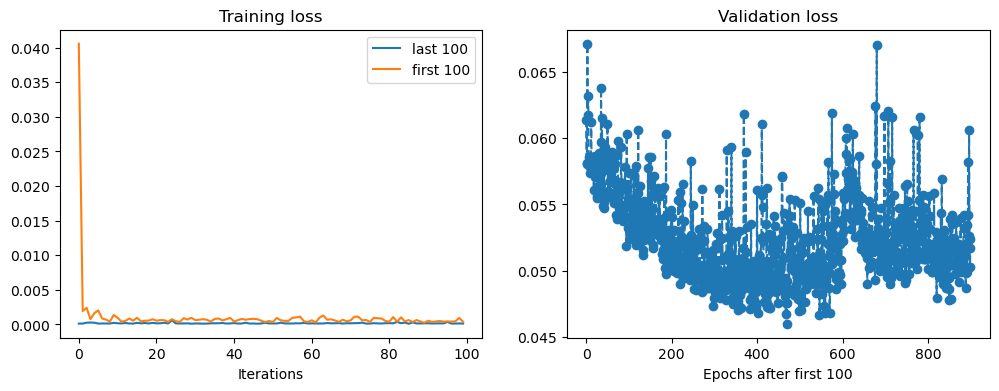

In [31]:
# PLOTTING LOSS
#plt.style.use('fivethirtyeight')

fig = plt.figure(figsize=(12,4))

# Plotting the last 100 values for training loss
ax1 = fig.add_subplot(1,2,1)
ax1.plot(losses_sum[-100:], label='last 100')
ax1.plot(losses_sum[:100], label='first 100')
ax1.set_xlabel('Iterations')
ax1.set_title('Training loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(losses_val[100:], '--o')
ax2.set_xlabel('Epochs after first 100')
ax2.set_title('Validation loss');

In [32]:
# Visualizing the latent space distribution - TEST DATA
inds = numpy.arange(len(test_data))

labels = test_data[:][1]
images = test_data[:][0]

#r_aux = labels[:, :3]

with torch.no_grad():
    
    # Creating reconstructions for test set
    r_new, _, _, z = VAE(images, labels, returnLatent=True)
    
    # generating samples
    
    generated = VAE.sample(labels, num_samples=len(labels))
    print(labels.shape, z.shape, generated.shape, r_new.shape)
 

torch.Size([39992, 9]) torch.Size([39992, 2]) torch.Size([39992, 3]) torch.Size([39992, 3])


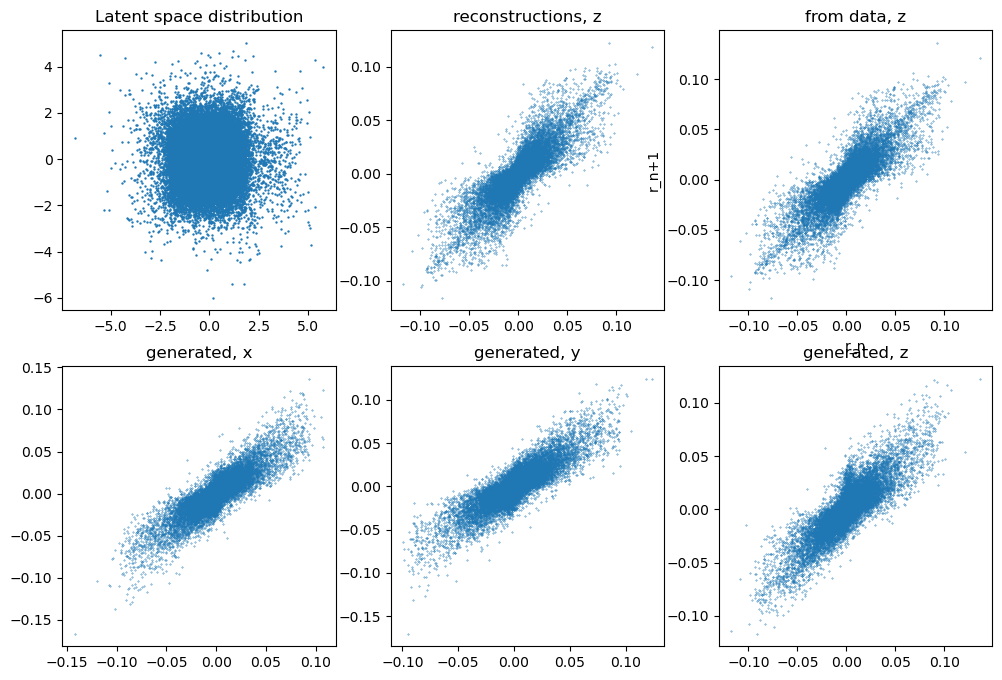

In [33]:
dim_labels = ['x', 'y', 'z']
dim_index = 2 # choose which dimension to plot

fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(2,3,1)
ax1.scatter(z[inds, 0], z[inds, 1], s=0.5)
ax1.set_title('Latent space distribution')

ax2 = fig.add_subplot(2,3,2)
ax2.scatter(r_aux[inds, dim_index], r_new[inds, dim_index], s=0.1)
ax2.set_title(f'reconstructions, {dim_labels[dim_index]}')

ax3 = fig.add_subplot(2,3,3)
ax3.scatter(r_aux[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
ax3.set_xlabel('r_n')
ax3.set_ylabel('r_n+1')
ax3.set_title(f'from data, {dim_labels[dim_index]}')

ax4 = fig.add_subplot(2,3,4)
ax4.scatter(r_aux[inds, 0], generated[inds, 0], s=0.1)
ax4.set_title('generated, x')

ax5 = fig.add_subplot(2,3,5)
ax5.scatter(r_aux[inds, 1], generated[inds, 1], s=0.1)
ax5.set_title('generated, y')

ax6 = fig.add_subplot(2,3,6)
ax6.scatter(r_aux[inds, 2], generated[inds, 2], s=0.1)
ax6.set_title('generated, z')

fig.show()

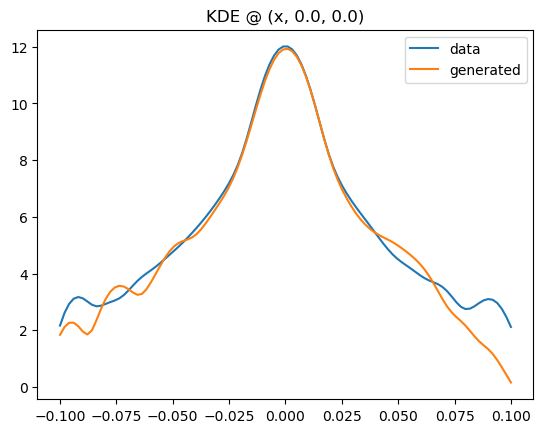

In [34]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(r_nxt)

# Generated data
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(generated);

# Reconstructed data - not particularly interesting (?)
#kde3 = KernelDensity(bandwidth=0.005)
#kde3.fit(r_new)

# Draw grid
num_gridpts = 100
grid_1d = numpy.linspace(-0.10, 0.10, num_gridpts)
c_yz = 0.0
E = numpy.full((num_gridpts,2), c_yz)
grid_slice = numpy.concatenate((grid_1d[:, numpy.newaxis], E), axis=1)

# Evaluate 3D KDE on grid
pdf_data = kde1.score_samples(grid_slice)
#pdf_rec = kde2.score_samples(grid_1d.reshape(-1,1))
pdf_gen = kde2.score_samples(grid_slice)

# Plotting 3D KDE evaluation at (x, 0, 0)
plt.plot(grid_slice[:,0], pdf_data, label='data')
#plt.plot(grid[:,0], pdf_rec, label='reconstructed')
plt.plot(grid_slice[:,0], pdf_gen, label='generated')
plt.title(f'KDE @ (x, {c_yz}, {c_yz})')
plt.legend()
plt.show()

#pdf_data

In [35]:
#xv, yv, zv = numpy.meshgrid(grid_1d, grid_1d, grid_1d)
grid_reduced = numpy.linspace(-0.10, 0.10, 20)
grid_3d = numpy.array([[x, y, z] for x in grid_reduced for y in grid_reduced for z in grid_reduced])
grid_3d.shape, grid_slice.shape
pdf_data_3d = kde1.score_samples(grid_3d)
pdf_gen_3d = kde2.score_samples(grid_3d)



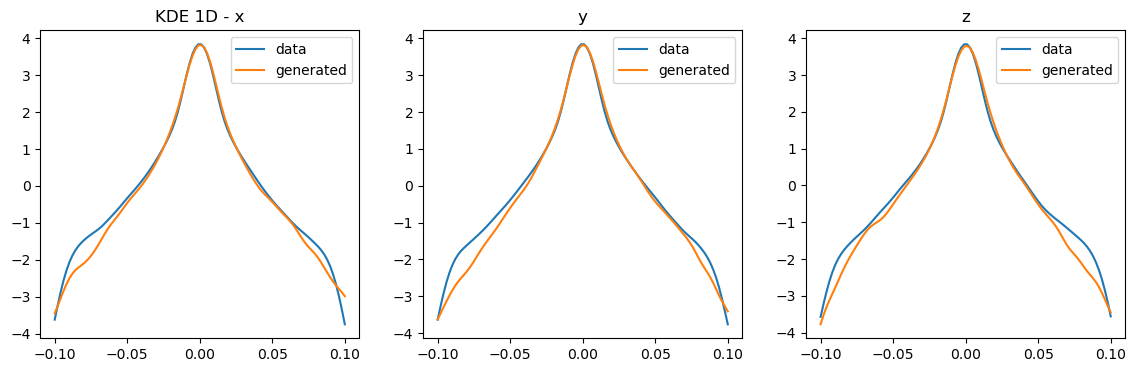

In [36]:
plot_labels = ['data', 'generated']
plot_titles = ['KDE 1D - x', 'y', 'z']

fig = plt.figure(figsize=(14,4))

for i in range(len(plot_titles)):
    
    # Kernel Density Estimation - extracting 1 coordinate
    
    # Original data
    kde1_1d = KernelDensity(bandwidth=0.005)
    kde1_1d.fit(r_nxt[:, i].reshape(-1,1))
    
    # Generated data
    kde2_1d = KernelDensity(bandwidth=0.005)
    kde2_1d.fit(generated[:, i].reshape(-1,1));
    
    pdf_data_1d = kde1_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_gen_1d = kde2_1d.score_samples(grid_1d.reshape(-1,1))

    ax = fig.add_subplot(1, 3, i+1)
    ax.plot(grid_1d, pdf_data_1d, label = 'data')
    ax.plot(grid_1d, pdf_gen_1d, label = 'generated')
    ax.set_title(plot_titles[i])
    ax.legend()

fig.show()

In [37]:
print("Wasserstein Distance")
wasserstein_distance_nd(pdf_data_3d, pdf_gen_3d)

Wasserstein Distance


1.0116771748217153

In [39]:
plot_this = False # <==3


if plot_this:

    fig = plt.figure(figsize=(12,10))
    
    ax1 = fig.add_subplot(2,3,1)
    ax1.scatter(r_aux[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax1.set_xlabel('r_n')
    ax1.set_ylabel('r_n+1')
    ax1.set_title('from data')
    
    ax2 = fig.add_subplot(2,3,2, sharey=ax1)
    ax2.scatter(r_aux[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax2.set_xlabel('r_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title('from reconstruction')
    
    ax3 = fig.add_subplot(2,3,3, sharey=ax1)
    ax3.scatter(r_aux[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax3.set_xlabel('r_n')
    ax3.set_ylabel('r_n+1')
    ax3.set_title('generated')
    
    ax4 = fig.add_subplot(2,3,4)
    ax4.scatter(v[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax4.set_xlabel('v_n')
    ax4.set_ylabel('r_n+1')
    
    ax5 = fig.add_subplot(2,3,5, sharey=ax4)
    ax5.scatter(v[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax5.set_xlabel('v_n')
    ax5.set_ylabel('r_n+1')
    
    ax6 = fig.add_subplot(2,3,6, sharey=ax4)
    ax6.scatter(v[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax6.set_xlabel('v_n')
    ax6.set_ylabel('r_n+1')
    
    fig.show()

In [120]:
# Save model parameters
save_model = True
if save_model==True:
    model_name = 'model_state_piri_S2_3.pt'
    torch.save(VAE.state_dict(), model_name)
    print(f'Model parameters saved under "{model_name}"')

Model parameters saved under "model_state_piri_S2_3.pt"
